# Lab 0: Exercise 5 Pandas Data Analysis

In [23]:
import pandas as pd
import numpy as np

np.random.seed(42)
n_students = 200

data = {
    'student_id': range(1000, 1000 + n_students),
    'major': np.random.choice(['CS', 'Math', 'Physics', 'Biology'], n_students),
    'year': np.random.choice([1, 2, 3, 4], n_students),
    'exam_score': np.random.normal(75, 10, n_students).clip(0, 100),
    'assignments_completed': np.random.randint(0, 11, n_students),
    'hours_studied': np.random.normal(15, 5, n_students).clip(1, 40)
}

df = pd.DataFrame(data)

df.loc[np.random.choice(n_students, 10), 'exam_score'] = np.nan
df.loc[np.random.choice(n_students, 5), 'hours_studied'] = np.nan

In [24]:
print(df.info())
print(df.describe())
print(df.isnull().sum())

df['exam_score'] = df['exam_score'].fillna(
    df.groupby('major')['exam_score'].transform('mean')
)

df['hours_studied'] = df['hours_studied'].fillna(df.groupby('year')['hours_studied'].transform('median'))


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             200 non-null    int64  
 1   major                  200 non-null    object 
 2   year                   200 non-null    int64  
 3   exam_score             190 non-null    float64
 4   assignments_completed  200 non-null    int64  
 5   hours_studied          195 non-null    float64
dtypes: float64(2), int64(3), object(1)
memory usage: 9.5+ KB
None
        student_id        year  exam_score  assignments_completed  \
count   200.000000  200.000000  190.000000             200.000000   
mean   1099.500000    2.615000   75.510638               4.700000   
std      57.879185    1.159091    9.582797               3.239207   
min    1000.000000    1.000000   42.587327               0.000000   
25%    1049.750000    2.000000   68.206910               2.000000   

In [25]:
print(df.groupby('major')['exam_score'].mean())
print(df.groupby('major')['exam_score'].mean().idxmax())
corr = df['hours_studied'].corr(df['exam_score'])

def categorize(score):
  if score > 90:
    return 'Excellent'
  elif score >= 80:
    return 'Good'
  elif score >= 70:
    return 'Average'
  else:
    return 'Needs Improvement'

df['performance']=df['exam_score'].apply(categorize)
print(df['performance'].value_counts())

major
Biology    75.503150
CS         76.425184
Math       74.683689
Physics    75.406509
Name: exam_score, dtype: float64
CS
performance
Average              77
Needs Improvement    59
Good                 52
Excellent            12
Name: count, dtype: int64


In [26]:
datasetSummary = df.groupby(['major','year']).agg(numStudents=('student_id','count'),
                                                  avgExamScore=('exam_score','mean'),
                                                  avgHoursStudied=('hours_studied','mean'))

print(datasetSummary)

top5Students = df.nlargest(5, 'exam_score', keep='all')
print(top5Students)

pivotTable = pd.pivot_table(
    df, values='exam_score', index='major',
    columns='year',aggfunc='mean'
)

print(pivotTable)

              numStudents  avgExamScore  avgHoursStudied
major   year                                            
Biology 1              13     76.570059        12.677806
        2              12     74.899613        13.426372
        3              14     80.178476        14.486815
        4              15     70.697689        14.253944
CS      1              12     77.098194        13.039480
        2               7     76.155936        13.995784
        3               9     72.347626        15.039892
        4              18     78.119997        16.275541
Math    1              11     74.053167        19.001215
        2               9     81.226714        12.345468
        3              10     72.017537        15.175871
        4              16     73.103066        17.419175
Physics 1              13     77.828686        13.489911
        2              12     73.277734        14.616778
        3              17     73.134319        14.199901
        4              12     7

# Lab0 Exercise 6 Data Visualization

Text(0.5, 1.0, 'Exam Scores by Major')

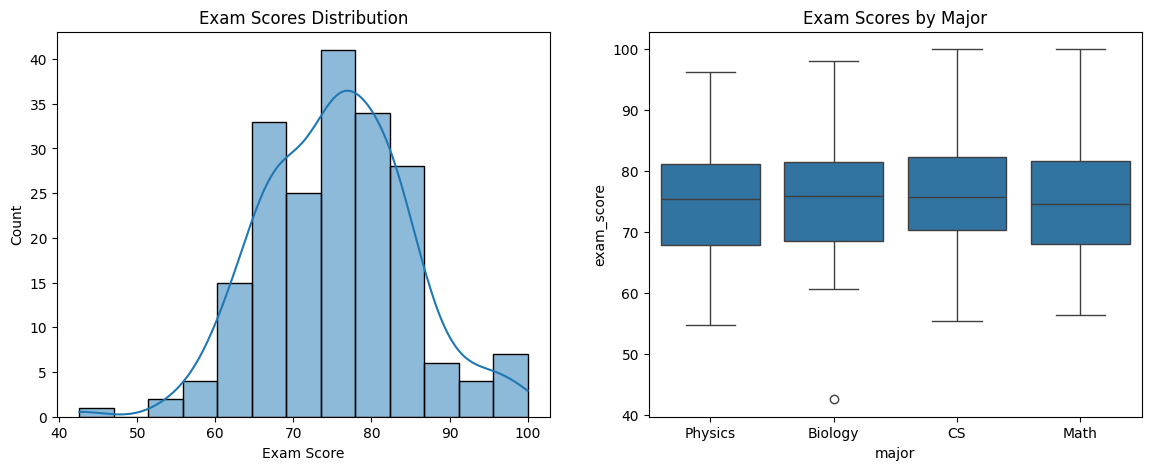

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1,2,figsize=(14,5))
sns.histplot(df['exam_score'],kde=True, ax=axes[0])
axes[0].set_title("Exam Scores Distribution")
axes[0].set_xlabel("Exam Score")

sns.boxplot(data=df, x='major', y='exam_score', ax=axes[1])
axes[1].set_title("Exam Scores by Major")


Text(0, 0.5, 'Exam Score')

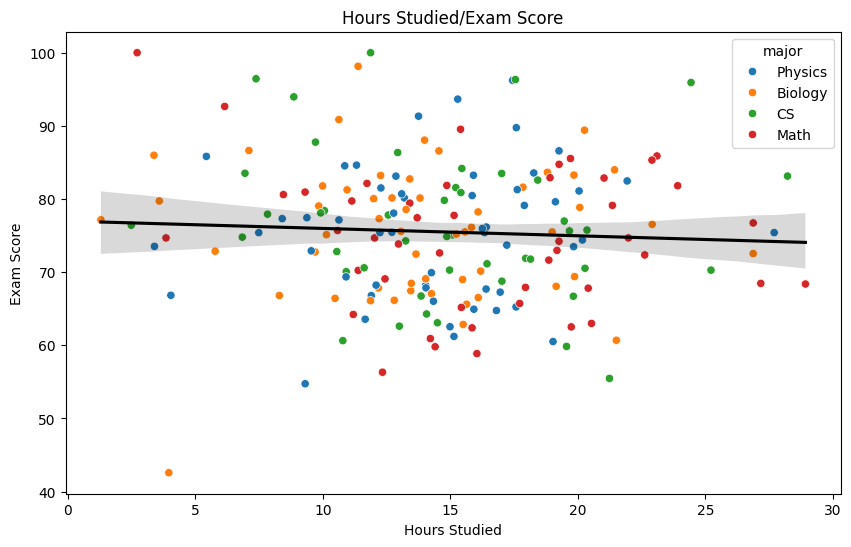

In [28]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df, x = 'hours_studied', y = 'exam_score', hue = 'major'
)

sns.regplot(
    data=df, x='hours_studied', y='exam_score', scatter=False, color='black'
)

plt.title("Hours Studied/Exam Score")
plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")


In [ ]:
fig, axes = plt.subplots(2,2,figsize=(15,10))

sns.barplot(data=df,x='major', y='exam_score', ax=axes[0,0])
axes[0,0].set_title("Averagg Exam Score by Major")

sns.countplot(data=df,x='year', ax=axes[0,1])
axes[0,1].set_title("Number of Students by Year")

corr = df.select_dtypes(include=np.number).corr()
sns.heatmap(corr,annot=True,cmap='coolwarm',ax=axes[1,0])
axes[1,0].set_title("Correlation Matrix of Numerical Columns")

sns.violinplot(data=df, x='performance', y='exam_score', ax=axes[1,1])
axes[1,1].set_title("Exam Score Distribution by Performance category")